<h1 style="color:teal; font-size:45px; font-family:'Verdana', sans-serif; font-weight:bold; margin-bottom: 5px;">
Rapport - Projet HDDL
</h1>

<p style="color:#444; font-size:12px; font-family:'Verdana', sans-serif; border-bottom: 3px solid #2980b9; padding-bottom: 10px; font-weight:bold; margin-top: 0px;">
Dataset - The Oxford-IIIT Pet Dataset 
</p>
<p style="font-size:16px; font-family:'Verdana'; color:#34495e; margin-top: 0px; text-align: right;">
EHRHART Elsa, HOSSEINI Arman, SLISSE Paul, STAUB Guillaume
</p>

<div style="margin-top: 100px;">
</div>
<div style="border-left: 6px solid #2980b9; background-color: #f0f8ff; padding: 15px; margin: 20px 0; font-family:Verdana; font-size:16px;">
<h2 style="color:#2980b9; ">Sommaire</h2>
<ul style="list-style-type: none; padding-left: 0;">
    <li><a href="#chap0" style="color:#2c3e50; text-decoration: none;"><strong>0. Librairies</strong></a></li>
    <li><a href="#chap1" style="color:#2c3e50; text-decoration: none;"><strong>1. </strong></a></li>
    <ul style="list-style-type: circle; padding-left: 60px;">
        <li><a href="#dupl" style="color:#2c3e50; text-decoration: none;">1.1 </a></li>
        <li><a href="#red" style="color:#2c3e50; text-decoration: none;">1.2 </a></li>
        <li><a href="#trans" style="color:#2c3e50; text-decoration: none;">1.3 </a></li>
    </ul>
    <li><a href="#chap2" style="color:#2c3e50; text-decoration: none;"><strong>2. </strong></a></li>
    <ul style="list-style-type: circle; padding-left: 60px;">
        <li><a href="#21" style="color:#2c3e50; text-decoration: none;">2.1 </a></li>
        <li><a href="#22" style="color:#2c3e50; text-decoration: none;">2.2 </a></li>
    </ul>
<li><a href="#chap3" style="color:#2c3e50; text-decoration: none;"><strong>3. </strong></a></li>
    <ul style="list-style-type: circle; padding-left: 60px;">
        <li><a href="#31" style="color:#2c3e50; text-decoration: none;">3.1 </a></li>
        <li><a href="#32" style="color:#2c3e50; text-decoration: none;">3.2 </a></li>
        <li><a href="#33" style="color:#2c3e50; text-decoration: none;">3.3 </a></li>
        <li><a href="#34" style="color:#2c3e50; text-decoration: none;">3.4 </a></li>
        <li><a href="#35" style="color:#2c3e50; text-decoration: none;">3.5 </a></li>
        <li><a href="#36" style="color:#2c3e50; text-decoration: none;">3.6 </a></li>
        <li><a href="#37" style="color:#2c3e50; text-decoration: none;">3.7 </a></li>
        <li><a href="#38" style="color:#2c3e50; text-decoration: none;">3.8 </a></li>
        <li><a href="#39" style="color:#2c3e50; text-decoration: none;">3.9 </a></li>
    </ul>
<li><a href="#chap4" style="color:#2c3e50; text-decoration: none;"><strong>4. </strong></a></li>
</ul>
</div>

<div id="chap0"></div>
<h2 style="color:#2980b9; font-size:32px; font-family:'Trebuchet MS', sans-serif; margin-top:30px;">
    0. Librairies
</h2>

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np

# Data visualization
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
import matplotlib.cm as cm

import random
import pandas
import math
import pandas as pd





# Utils
import os
import shutil
import time
import re
import cv2
from PIL import Image

# Maths - Stats
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd
import random as rd

#torch
import torch
import torch.nn as nn
import torch.optim as optim

import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms, models

from tqdm import tqdm  # Barre de progression


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
#!pip install tqdm

In [4]:
def plot_colortable(colors, *, ncols=4, sort_colors=True):

    cell_width = 212
    cell_height = 22
    swatch_width = 48
    margin = 12

    # Sort colors by hue, saturation, value and name.
    if sort_colors is True:
        names = sorted(
            colors, key=lambda c: tuple(mcolors.rgb_to_hsv(mcolors.to_rgb(c))))
    else:
        names = list(colors)

    n = len(names)
    nrows = math.ceil(n / ncols)

    width = cell_width * ncols + 2 * margin
    height = cell_height * nrows + 2 * margin
    dpi = 72

    fig, ax = plt.subplots(figsize=(width / dpi, height / dpi), dpi=dpi)
    fig.subplots_adjust(margin/width, margin/height,
                        (width-margin)/width, (height-margin)/height)
    ax.set_xlim(0, cell_width * ncols)
    ax.set_ylim(cell_height * (nrows-0.5), -cell_height/2.)
    ax.yaxis.set_visible(False)
    ax.xaxis.set_visible(False)
    ax.set_axis_off()

    for i, name in enumerate(names):
        row = i % nrows
        col = i // nrows
        y = row * cell_height

        swatch_start_x = cell_width * col
        text_pos_x = cell_width * col + swatch_width + 7

        ax.text(text_pos_x, y, name, fontsize=14,
                horizontalalignment='left',
                verticalalignment='center')

        ax.add_patch(
            Rectangle(xy=(swatch_start_x, y-9), width=swatch_width,
                      height=18, facecolor=colors[name], edgecolor='0.7')
        )

    return fig

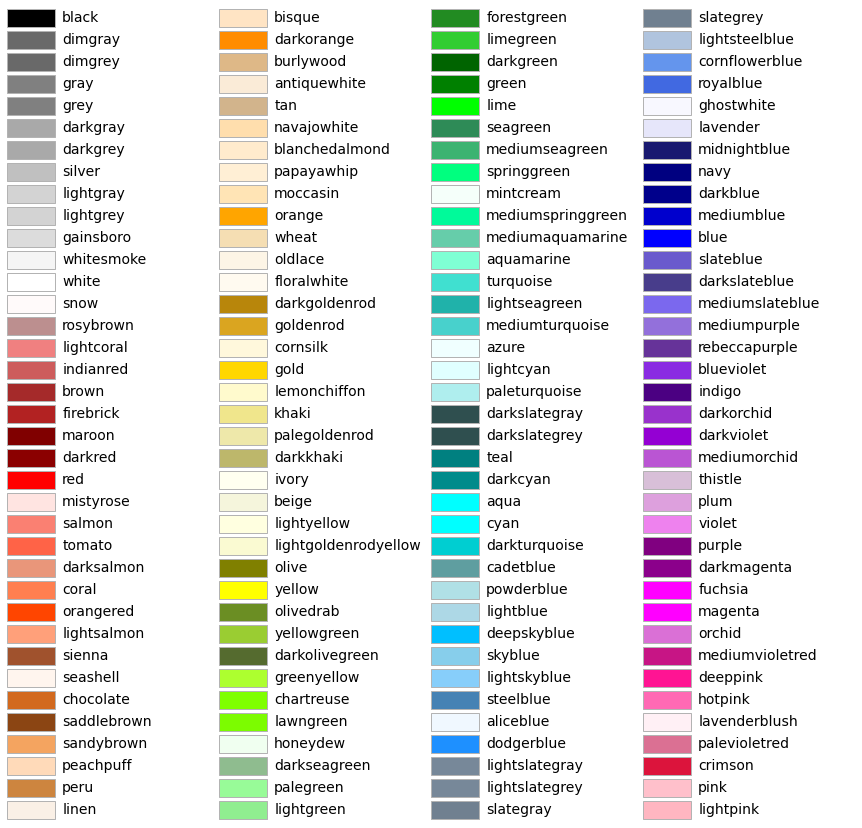

In [5]:
plot_colortable(mcolors.CSS4_COLORS)
plt.show()

# Importation des données

O. M. Parkhi, A. Vedaldi, A. Zisserman, C. V. Jawahar
   Cats and Dogs  
   IEEE Conference on Computer Vision and Pattern Recognition, 2012

Dataset contenant 37 categories d'animaux avec environ 200 images de chaque classe.

trimaps/ 	Trimap annotations for every image in the dataset  
		Pixel Annotations: 1: Foreground 2:Background 3: Not classified
xmls/		Head bounding box annotations in PASCAL VOC Format

list.txt	Combined list of all images in the dataset
- Each entry in the file is of following nature:
- Image CLASS-ID SPECIES BREED ID
- ID: 1:37 Class ids
- SPECIES: 1:Cat 2:Dog
- BREED ID: 1-25:Cat 1:12:Dog
All images with 1st letter as captial are cat images while images with small first letter are dog images.
trainval.txt	Files describing splits used in the paper.However,
test.txt	you are encouraged to try random splits.

(cf readme)


In [6]:
# --- 1. Définition des chemins ---
path = "./oxford-iiit-pet/"
annotations_path = os.path.join(path, "annotations")
images_path = os.path.join(path, "images") 

print(f"Chemin des annotations : {annotations_path}")
print(f"Chemin des images : {images_path}")

# --- 2. Lecture du fichier principal (list.txt) pour les labels ---

list_txt_path = os.path.join(annotations_path, "list.txt")
all_labels_data = []

try:
    with open(list_txt_path, 'r') as f:
        for line in f:
            line = line.strip()
            # Ignorer les lignes vides ou les commentaires (commençant par #)
            if not line or line.startswith('#'):
                continue
            
            # Diviser la ligne en gérant les espaces multiples
            parts = re.split(r'\s+', line)
            
            if len(parts) == 4:
                # Les fichiers d'annotation n'ont pas d'extension, mais les images si.
                image_name = parts[0] + ".jpg" 
                class_id = int(parts[1])
                species = int(parts[2])  # 1:Cat, 2:Dog
                breed_id = int(parts[3])
                
                # Mapper SPECIES (1:Cat, 2:Dog) à category (0:Cat, 1:Dog)
                # pour correspondre à la logique de votre ancien code.
                category = 0 if species == 1 else 1 # 0 pour Chat (Species 1), 1 pour Chien (Species 2)
                
                all_labels_data.append([image_name, class_id, species, breed_id, category])

    # Créer un DataFrame principal avec toutes les informations
    labels_df = pd.DataFrame(
        all_labels_data, 
        columns=['filename', 'CLASS-ID', 'SPECIES', 'BREED ID', 'category']
    )
    
    print(f"\nLabels chargés avec succès depuis list.txt. Total : {len(labels_df)} images.")
    # print(labels_df.head()) # Décommentez pour vérifier

except FileNotFoundError:
    print(f"ERREUR: Le fichier {list_txt_path} n'a pas été trouvé.")
    # Quitter ou gérer l'erreur
    exit()


Chemin des annotations : ./oxford-iiit-pet/annotations
Chemin des images : ./oxford-iiit-pet/images

Labels chargés avec succès depuis list.txt. Total : 7349 images.


In [7]:
# --- 4. Definition des ensembles train, validation et test ---
# 1. Première division : (Train + Validation) et Test
# Nous stratifions sur 'category' pour garder les proportions de chats/chiens
RANDOM_SEED=42

train_val_df, test_df = train_test_split(
    labels_df,
    test_size=0.3,
    random_state=RANDOM_SEED,
    stratify=labels_df['category']
)



# 2. Deuxième division : Train et Validation (à partir du train_val_df)
# Nous re-stratifions pour garantir les proportions dans les deux ensembles
total_train_df, total_validation_df = train_test_split(
    train_val_df,
    test_size=0.2, 
    random_state=RANDOM_SEED,
    stratify=train_val_df['category']
)

# Réinitialiser les index pour un affichage propre et éviter les erreurs de .copy()
total_train_df = total_train_df.reset_index(drop=True).copy()
total_validation_df = total_validation_df.reset_index(drop=True).copy()
test_df = test_df.reset_index(drop=True).copy()
train_val_df = train_val_df.reset_index(drop=True).copy()

# --- 6. Conversion de la colonne 'category' en string ---

total_train_df['category'] = total_train_df['category'].astype(str)
total_validation_df['category'] = total_validation_df['category'].astype(str)
test_df['category'] = test_df['category'].astype(str)
train_val_df['category'] = train_val_df['category'].astype(str)

total_train_df.drop('SPECIES',axis=1,inplace=True)
total_validation_df.drop('SPECIES',axis=1,inplace=True)
test_df.drop('SPECIES',axis=1,inplace=True)
train_val_df.drop('SPECIES',axis=1,inplace=True)

# --- 7. Affichage des résultats ---

print("\n--- Aperçu du DataFrame d'entraînement sans validation (train_val_df) ---")
print(train_val_df.head())
print(f"\nDistribution des classes (Train) :\n{train_val_df['category'].value_counts()}")

print("\n--- Aperçu du DataFrame d'entraînement (total_train_df) ---")
print(total_train_df.head())
print(f"\nDistribution des classes (Train) :\n{total_train_df['category'].value_counts()}")


print("\n--- Aperçu du DataFrame de validation (total_validation_df) ---")
print(total_validation_df.head())
print(f"\nDistribution des classes (Validation) :\n{total_validation_df['category'].value_counts()}")


print("\n--- Aperçu du DataFrame de test (test_df) ---")
print(test_df.head())
print(f"\nDistribution des classes (Test) :\n{test_df['category'].value_counts()}")


--- Aperçu du DataFrame d'entraînement sans validation (train_val_df) ---
                  filename  CLASS-ID  BREED ID category
0     basset_hound_112.jpg         4         3        1
1  scottish_terrier_77.jpg        31        21        1
2    saint_bernard_113.jpg        29        19        1
3          keeshond_99.jpg        19        13        1
4          keeshond_37.jpg        19        13        1

Distribution des classes (Train) :
category
1    3484
0    1660
Name: count, dtype: int64

--- Aperçu du DataFrame d'entraînement (total_train_df) ---
                    filename  CLASS-ID  BREED ID category
0  British_Shorthair_164.jpg        10         5        0
1       basset_hound_173.jpg         4         3        1
2             Bombay_105.jpg         8         4        0
3     wheaten_terrier_80.jpg        36        24        1
4          pomeranian_26.jpg        25        17        1

Distribution des classes (Train) :
category
1    2787
0    1328
Name: count, dtype: int6

In [8]:
#choisir N_train et N_test tels qu'il soient divisibles facilement par la taille de batch

N_train_val = train_val_df.shape[0]
N_train=total_train_df.shape[0]
N_validation=total_validation_df.shape[0]
N_test=test_df.shape[0]


print("Train data sans validation: %d images" %(N_train_val))
print("Train data: %d images" %(N_train))
print("Validation data: %d images" %(N_validation))
print("Test data: %d images" %(N_test))

Train data sans validation: 5144 images
Train data: 4115 images
Validation data: 1029 images
Test data: 2205 images


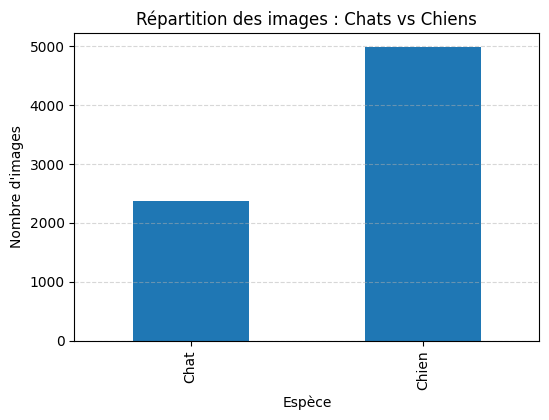

In [9]:
import matplotlib.pyplot as plt

# Comptage par catégorie (0 = chat, 1 = chien)
species_counts = labels_df['category'].value_counts().sort_index()
species_counts.index = ['Chat', 'Chien']

plt.figure(figsize=(6,4))
species_counts.plot(kind='bar')
plt.title("Répartition des images : Chats vs Chiens")
plt.ylabel("Nombre d'images")
plt.xlabel("Espèce")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

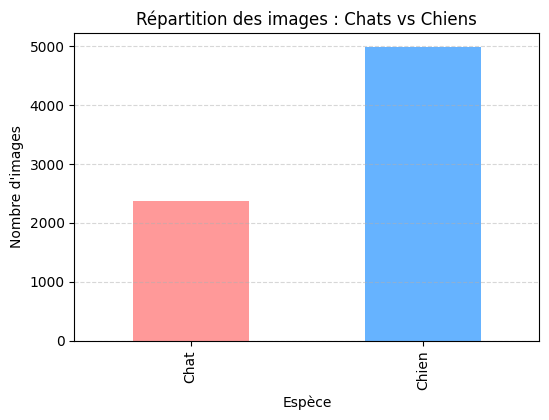

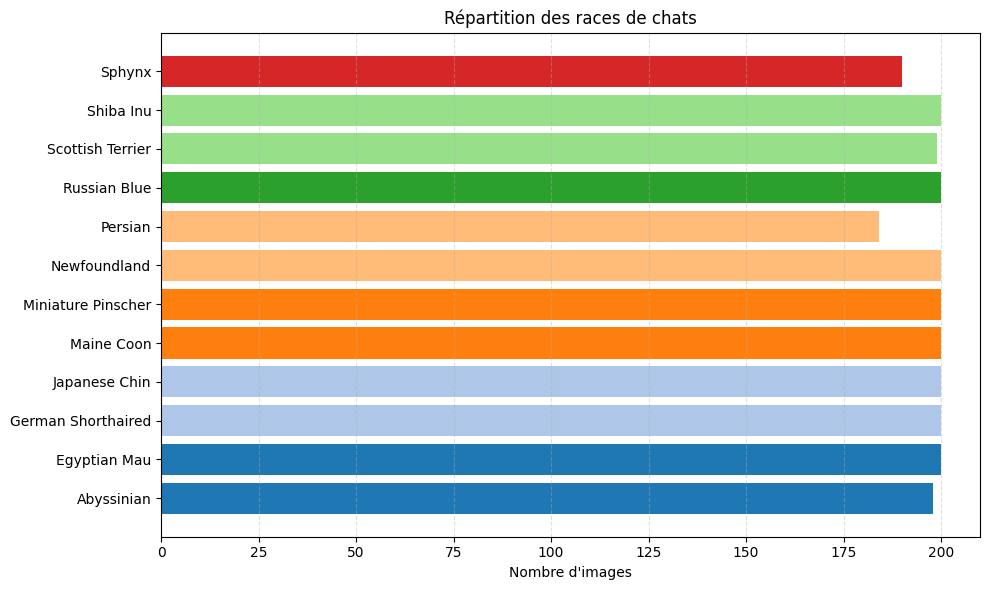

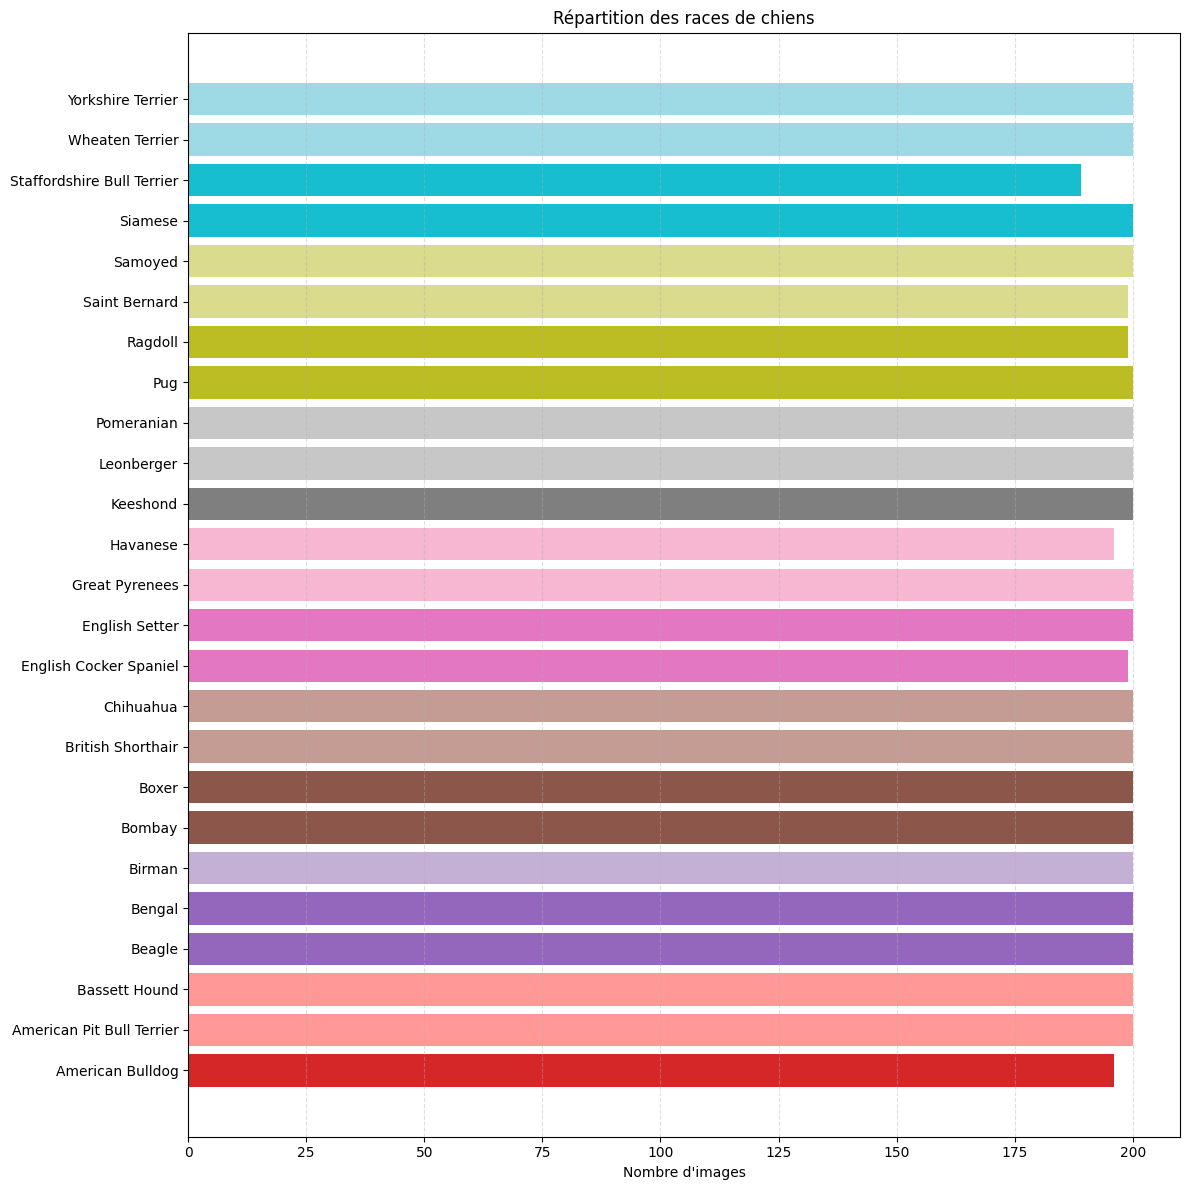

In [10]:
breed_names = [
    # 1–12 : Chats
    "Abyssinian", "Bengal", "Birman", "Bombay", "British Shorthair",
    "Egyptian Mau", "Maine Coon", "Persian", "Ragdoll", "Russian Blue",
    "Siamese", "Sphynx",

    # 13–37 : Chiens
    "American Bulldog", "American Pit Bull Terrier", "Bassett Hound",
    "Beagle", "Boxer", "Chihuahua", "English Cocker Spaniel",
    "English Setter", "German Shorthaired", "Great Pyrenees",
    "Havanese", "Japanese Chin", "Keeshond", "Leonberger",
    "Miniature Pinscher", "Newfoundland", "Pomeranian", "Pug",
    "Saint Bernard", "Samoyed", "Scottish Terrier", "Shiba Inu",
    "Staffordshire Bull Terrier", "Wheaten Terrier", "Yorkshire Terrier"
]

# Ajouter au DataFrame : nom de la race
labels_df["breed_name"] = labels_df["CLASS-ID"].apply(lambda i: breed_names[i - 1])
cat_color = "#ff9999"   # rose/rouge léger
dog_color = "#66b3ff"   # bleu clair

# Palette complète pour les races


race_colors = cm.tab20(np.linspace(0, 1, 37))  # 37 couleurs


species_counts = labels_df["category"].value_counts().sort_index()
species_counts.index = ["Chat", "Chien"]
colors = [cat_color, dog_color]

plt.figure(figsize=(6,4))
species_counts.plot(kind="bar", color=colors)
plt.title("Répartition des images : Chats vs Chiens")
plt.ylabel("Nombre d'images")
plt.xlabel("Espèce")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

breed_counts = labels_df["breed_name"].value_counts().sort_index()

# Préparation couleurs
race_colors = cm.tab20(np.linspace(0, 1, 37))  # 37 couleurs

# Chats (1–12)
cat_breeds = labels_df[labels_df["category"] == 0]["breed_name"].value_counts().sort_index()
cat_colors = race_colors[:12]

plt.figure(figsize=(10, 6))
plt.barh(cat_breeds.index, cat_breeds.values, color=cat_colors)
plt.xlabel("Nombre d'images")
plt.title("Répartition des races de chats")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Chiens (13–37)
dog_breeds = labels_df[labels_df["category"] == 1]["breed_name"].value_counts().sort_index()
dog_colors = race_colors[12:]

plt.figure(figsize=(12, 12))
plt.barh(dog_breeds.index, dog_breeds.values, color=dog_colors)
plt.xlabel("Nombre d'images")
plt.title("Répartition des races de chiens")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [12]:
#!pip install --user opencv-python
#!pip install opencv-python

Shape : (400, 600)
Valeurs uniques : [1 2 3]


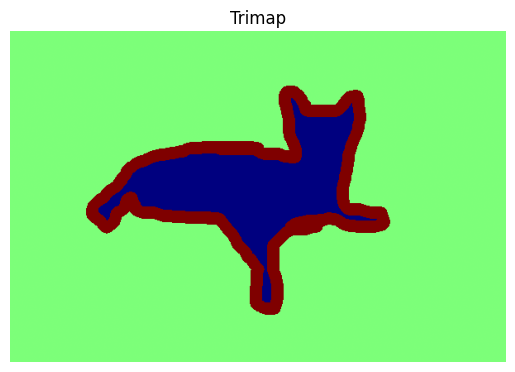

In [13]:
trimap_path = "./oxford-iiit-pet/annotations/trimaps/Abyssinian_1.png"

# Charger le trimap directement en 2D
mask = cv2.imread(trimap_path, cv2.IMREAD_UNCHANGED)

print("Shape :", mask.shape)  # devrait être (H, W)
print("Valeurs uniques :", np.unique(mask))

import matplotlib.pyplot as plt

plt.imshow(mask, cmap="jet")
plt.title("Trimap")
plt.axis("off")
plt.show()



In [14]:
image_files = sorted(os.listdir(images_path))
image_files = [f for f in os.listdir(images_path) if f.lower().endswith(".jpg")]
mask_files = sorted(os.listdir(os.path.join(annotations_path, "trimaps")))

# Récupérer les noms sans extension
image_names = [i.replace(".jpg", "") for i in image_files]
mask_names = [m.replace(".png", "") for m in mask_files]

# Filtrer les masques correspondant à des images
mask_for_images = [m for m in mask_names if m in image_names]

print("Nombre de masques correspondant à des images :", len(mask_for_images))

Nombre de masques correspondant à des images : 7390


In [17]:
# Attention très long
size_mismatches = []

for img_file in image_files:
    img_name = img_file.replace(".jpg", "")
    mask_file = img_name + ".png"

    img = Image.open(os.path.join(images_path, img_file))
    mask = Image.open(os.path.join(annotations_path, "trimaps", mask_file))

    if img.size != mask.size:
        size_mismatches.append((img_file, img.size, mask.size))

print(f"Problèmes de dimensions : {len(size_mismatches)}")
if size_mismatches:
    for m in size_mismatches[:10]:
        print(m)

KeyboardInterrupt: 

In [15]:
invalid_mask_values = []

mask_path = os.path.join(annotations_path, "trimaps")

# Filtrer uniquement les vrais fichiers PNG
mask_files = [f for f in os.listdir(mask_path) 
              if f.lower().endswith(".png") and not f.startswith("._")]

print(f"Nombre de masques valides : {len(mask_files)}")

for mask_file in mask_files:
    mask = np.array(Image.open(os.path.join(mask_path, mask_file)))
    unique_vals = np.unique(mask)

    # Le dataset utilise les valeurs 1, 2, 3
    if not set(unique_vals).issubset({1, 2, 3}):
        invalid_mask_values.append((mask_file, unique_vals))

print(f"Masques avec valeurs incorrectes : {len(invalid_mask_values)}")
if invalid_mask_values:
    for m in invalid_mask_values[:5]:
        print(m)

Nombre de masques valides : 7390


KeyboardInterrupt: 

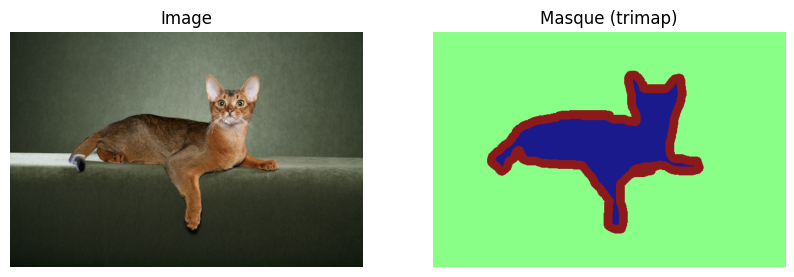

In [16]:
def show_image_with_mask(image_name):
    img_path = os.path.join(images_path, image_name + ".jpg")
    mask_path = os.path.join(annotations_path, "trimaps", image_name + ".png")

    img = np.array(Image.open(img_path))
    mask = np.array(Image.open(mask_path))

    plt.figure(figsize=(10,5))

    # Afficher image
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Image")
    plt.axis("off")

    # Afficher masque (couleurs distinctes)
    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap="jet", alpha=0.9)
    plt.title("Masque (trimap)")
    plt.axis("off")

    plt.show()


# Exemple :
show_image_with_mask("Abyssinian_1")


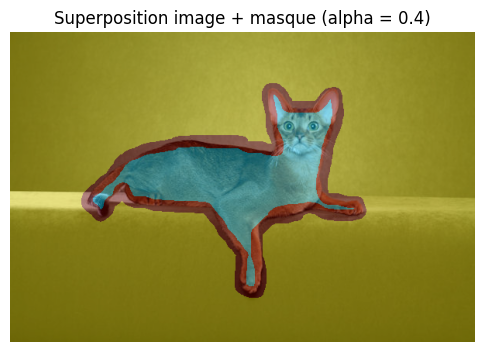

In [17]:
def show_overlay(image_name):
    img_path = os.path.join(images_path, image_name + ".jpg")
    mask_path = os.path.join(annotations_path, "trimaps", image_name + ".png")

    img = np.array(Image.open(img_path))
    mask = np.array(Image.open(mask_path))

    # Créer un overlay coloré
    cmap = plt.get_cmap("jet")
    mask_color = cmap(mask / mask.max())[..., :3]  # ignore alpha

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.imshow(mask_color, alpha=0.4)
    plt.title("Superposition image + masque (alpha = 0.4)")
    plt.axis("off")
    plt.show()

# Exemple :
show_overlay("Abyssinian_1")


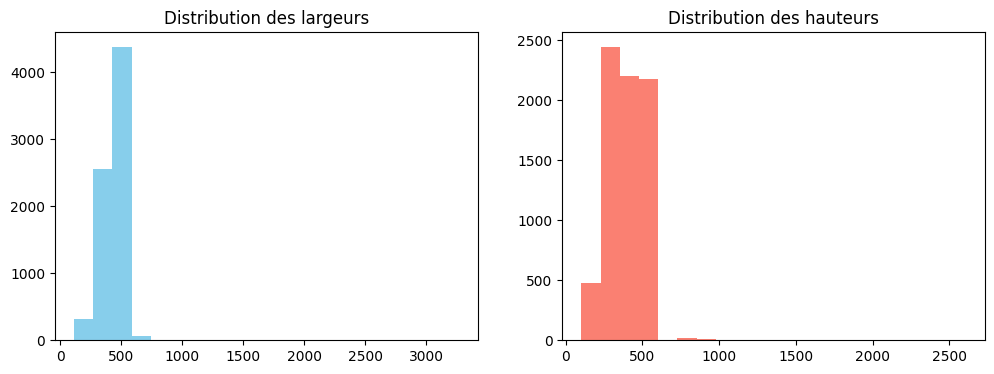

In [18]:
widths, heights = [], []

for img_file in labels_df['filename']:  # tester sur un échantillon si dataset lourd
    img_path = os.path.join(images_path, img_file)
    img = Image.open(img_path)
    w, h = img.size
    widths.append(w)
    heights.append(h)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(widths, bins=20, color='skyblue')
plt.title("Distribution des largeurs")
plt.subplot(1,2,2)
plt.hist(heights, bins=20, color='salmon')
plt.title("Distribution des hauteurs")
plt.show()

In [46]:
class PandasDataset(Dataset):
    def __init__(self, df, img_dir, skip_lines = 6, transform=None, label_col="label_enc"):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["filename"])
        label = int(row[self.label_col])   # label déjà entier

        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long)

In [30]:
import gc

del model
del train_loader, test_loader  # ou ceux que tu n’utilises plus
gc.collect()
torch.cuda.empty_cache()

In [31]:
# ATTENTION LONG SUR CPU

# --- Hyperparamètres ---
img_size = 200
batch_size = 64 #Réduire la taille de batch en fonction de la CGU
epochs = 5
learning_rate = 0.001
val_split = 0.2  # 20% pour validation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# --- Transformations des images ---
transform_ourCNN = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])

"""
# --- Dataset personnalisé ---
class CatDogDataset(Dataset):
    def __init__(self, file_list_path, img_dir, skip_lines = 6, transform=None):
        with open(file_list_path, 'r') as f:
            lines = [line.strip() for line in f.readlines()]
        lines = lines[skip_lines:]
        self.files = [line.split()[0] + '.jpg' for line in lines]
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        filename = self.files[idx]
        img_path = os.path.join(self.img_dir, filename)
        image = Image.open(img_path).convert('RGB')

        # Classe : majuscule → chat (0), minuscule → chien (1)
        label = 0 if filename[0].isupper() else 1

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)
"""

# --- Chargement du dataset et split ---
train_dataset = PandasDataset(train_val_df, './oxford-iiit-pet/images', transform = transform_ourCNN, label_col = "category")
test_dataset = PandasDataset(test_df, './oxford-iiit-pet/images', transform = transform_ourCNN, label_col = "category")

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train: {len(train_dataset)} images | Validation: {len(test_dataset)} images")

# --- Définition du CNN ---
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*(img_size//8)*(img_size//8), 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512,1),
            nn.Sigmoid()
        )
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model = SimpleCNN().to(device)

# --- Perte et optimiseur ---
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# --- Entraînement ---
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = (outputs >= 0.5).float()
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = running_corrects.double() / len(train_loader.dataset)

    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

# --- Évaluation sur validation ---
model.eval()
val_corrects = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()
        outputs = model(inputs)
        preds = (outputs >= 0.5).float()
        val_corrects += torch.sum(preds == labels.data)

val_acc = val_corrects.double() / len(test_loader.dataset)
print(f"Validation Accuracy: {val_acc:.4f}")

# --- Sauvegarde du modèle ---
torch.save(model.state_dict(), 'cat_dog_cnn.pth')
print("Modèle sauvegardé !")

cuda
Train: 5144 images | Validation: 2205 images
Epoch 1/5 | Loss: 0.6803 | Acc: 0.6602
Epoch 2/5 | Loss: 0.5702 | Acc: 0.6934
Epoch 3/5 | Loss: 0.5509 | Acc: 0.7129
Epoch 4/5 | Loss: 0.5227 | Acc: 0.7414
Epoch 5/5 | Loss: 0.4812 | Acc: 0.7679
Validation Accuracy: 0.7868
Modèle sauvegardé !


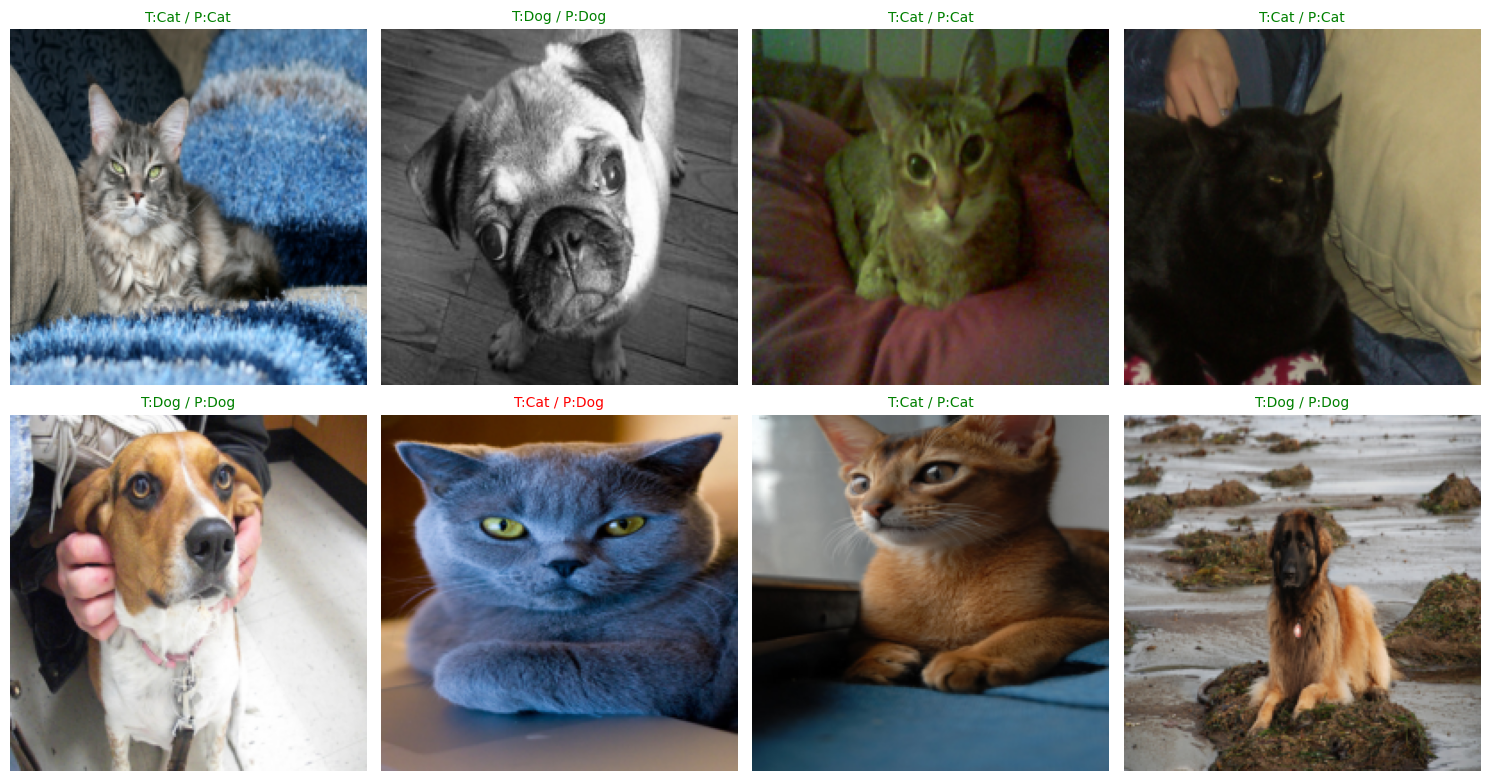

In [33]:
def show_val_predictions(model, val_loader, class_names=["Cat", "Dog"], num_images=8, device="cpu"):
    model.eval()
    images_shown = 0

    plt.figure(figsize=(15, 8))

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            # Prédiction
            outputs = model(images)
            preds = (outputs > 0.5).long().view(-1)  # pour BCEWithLogitsLoss

            images = images.cpu()
            labels = labels.cpu()
            preds = preds.cpu()

            for i in range(images.size(0)):

                if images_shown >= num_images:
                    plt.tight_layout()
                    plt.show()
                    return

                img = images[i].permute(1, 2, 0).numpy()
                img = (img * 0.5 + 0.5).clip(0, 1)  # dénormalisation

                plt.subplot(2, num_images//2, images_shown + 1)
                plt.imshow(img)
                plt.axis("off")

                true_lbl = class_names[int(labels[i].item())]
                pred_lbl = class_names[int(preds[i].item())]

                color = "green" if true_lbl == pred_lbl else "red"

                plt.title(f"T:{true_lbl} / P:{pred_lbl}", color=color, fontsize=10)

                images_shown += 1

show_val_predictions(model, test_loader, class_names=["Cat", "Dog"], device=device)


On essaie maintenant de Fine-Tune le réseau de neurones préexistant VGG16 et de l'appliquer à la tâche de classification chat / chien sur notre jeu de données augmenté.

In [35]:
# --- Hyperparamètres ---
img_size = 224
epochs = 5
learning_rate = 0.001
val_split = 0.2  # 20% pour validation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# --- Dataset personnalisé ---
print(f"Train: {len(train_dataset)} images | Validation: {len(test_dataset)} images")

model_vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

# Geler les couches convolutionnelles
for param in model_vgg.features.parameters():
    param.requires_grad = False

# Remplacer le classifieur final
num_features = model_vgg.classifier[6].in_features
model_vgg.classifier[6] = nn.Linear(num_features, 1)  # 1 sortie pour binaire
model_vgg = model_vgg.to(device)

criterion = nn.BCEWithLogitsLoss()  # sortie 1 neurone
optimizer = optim.Adam(model_vgg.classifier[6].parameters(), lr=1e-4)

for epoch in range(epochs):
    model_vgg.train()
    running_loss = 0.0
    running_corrects = 0

    loop = tqdm(train_loader, total=len(train_loader), desc=f"Epoch [{epoch+1}/{epochs}]")
    for inputs, labels in loop:
        inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()

        optimizer.zero_grad()
        outputs = model_vgg(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        running_corrects += torch.sum(preds == labels.data)

        loop.set_postfix(loss=running_loss/((loop.n+1)*batch_size),
                         acc=(running_corrects.double()/((loop.n+1)*batch_size)).item())

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = running_corrects.double() / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

model_vgg.eval()
val_corrects = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()
        outputs = model_vgg(inputs)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        val_corrects += torch.sum(preds == labels.data)

val_acc = val_corrects.double() / len(test_loader.dataset)
print(f"Test Accuracy: {val_acc:.4f}")

torch.save(model_vgg.state_dict(), 'vgg16_cat_dog.pth')
print("Modèle sauvegardé !")

cuda
Train: 5144 images | Validation: 2205 images


Epoch [1/5]: 100%|████████| 81/81 [00:30<00:00,  2.62it/s, acc=0.889, loss=0.33]


Epoch 1/5 | Loss: 0.3321 | Acc: 0.8960


Epoch [2/5]: 100%|███████| 81/81 [00:30<00:00,  2.65it/s, acc=0.964, loss=0.143]


Epoch 2/5 | Loss: 0.1437 | Acc: 0.9716


...

Epoch 3/5 | Loss: 0.1008 | Acc: 0.9751


Epoch [4/5]: 100%|██████| 81/81 [00:30<00:00,  2.62it/s, acc=0.974, loss=0.0791]


Epoch 4/5 | Loss: 0.0797 | Acc: 0.9817


Epoch [5/5]: 100%|██████| 81/81 [00:30<00:00,  2.65it/s, acc=0.975, loss=0.0686]


Epoch 5/5 | Loss: 0.0692 | Acc: 0.9829
Validation Accuracy: 0.9855
Modèle sauvegardé !


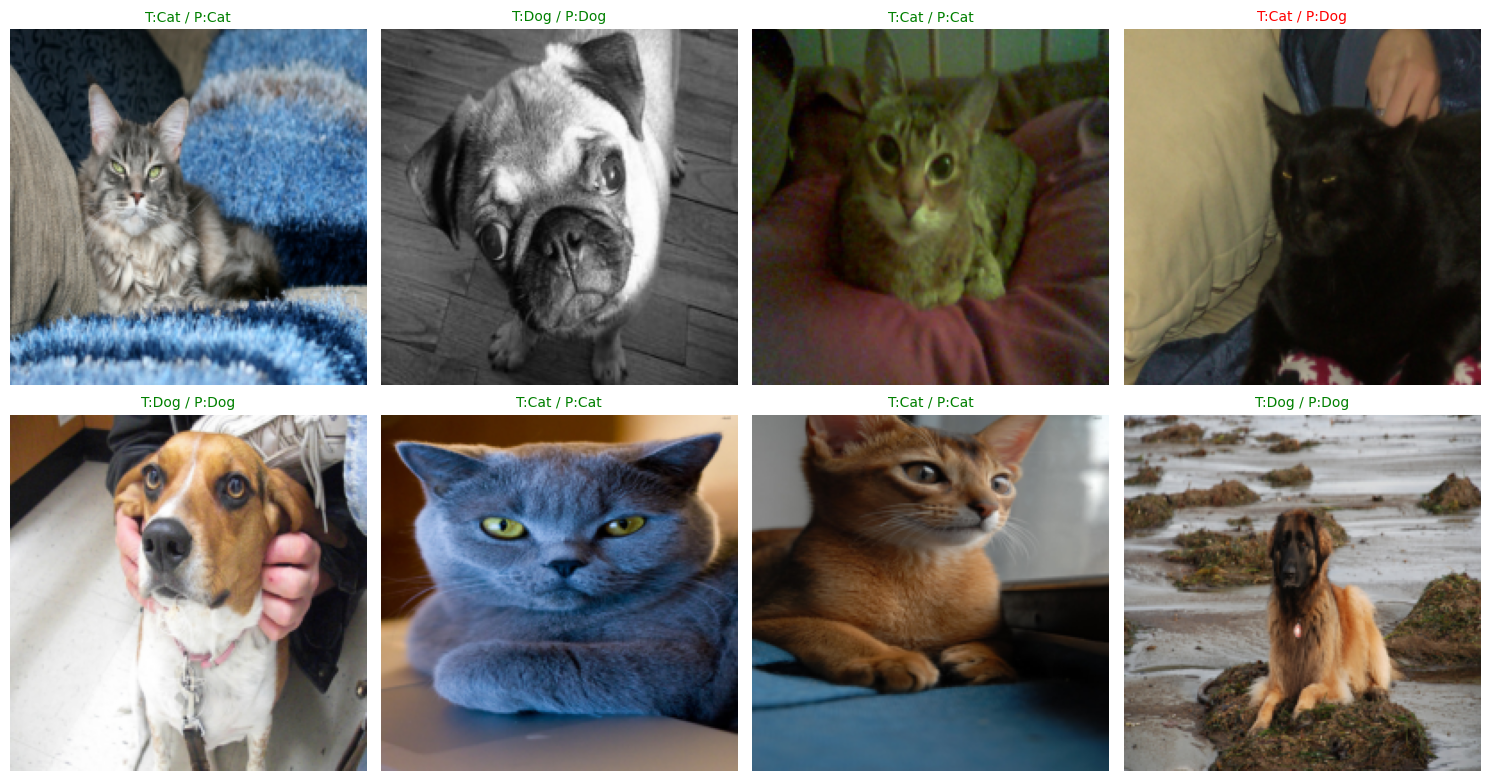

In [39]:
show_val_predictions(model_vgg, test_loader, class_names=["Cat", "Dog"], device=device)

In [43]:
train_val_df["label_enc"] = train_val_df["CLASS-ID"] - 1
test_df["label_enc"] = test_df["CLASS-ID"] - 1

In [51]:
train_val_df

,filename,CLASS-ID,BREED ID,category,label_enc
0,basset_hound_112.jpg,4,3,1,3
1,scottish_terrier_77.jpg,31,21,1,30
2,saint_bernard_113.jpg,29,19,1,28
3,keeshond_99.jpg,19,13,1,18
4,keeshond_37.jpg,19,13,1,18
...,...,...,...,...,...
5139,British_Shorthair_141.jpg,10,5,0,9
5140,samoyed_197.jpg,30,20,1,29
5141,Sphynx_96.jpg,34,12,0,33
5142,havanese_131.jpg,17,11,1,16


In [50]:
test_df

,filename,CLASS-ID,BREED ID,category,label_enc
0,Maine_Coon_35.jpg,21,7,0,20
1,pug_130.jpg,26,18,1,25
2,Abyssinian_158.jpg,1,1,0,0
3,Bombay_46.jpg,8,4,0,7
4,beagle_34.jpg,5,4,1,4
...,...,...,...,...,...
2200,beagle_38.jpg,5,4,1,4
2201,wheaten_terrier_8.jpg,36,24,1,35
2202,Russian_Blue_90.jpg,28,10,0,27
2203,miniature_pinscher_97.jpg,22,15,1,21


In [85]:
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

batch_size = 64 

vgg16_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225],
    )
])

train_dataset = PandasDataset(train_val_df, './oxford-iiit-pet/images', transform=vgg16_transforms)
test_dataset   = PandasDataset(test_df, './oxford-iiit-pet/images',  transform=vgg16_transforms)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader   = DataLoader(test_dataset, batch_size=batch_size)

# --- Hyperparamètres ---
img_size = 224
epochs = 10
learning_rate = 0.001
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# --- Dataset personnalisé ---
print(f"Train: {len(train_dataset)} images | Validation: {len(test_dataset)} images")

model_vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

# Geler les couches convolutionnelles
for param in model_vgg.features.parameters():
    param.requires_grad = False

# Remplacer le classifieur final
num_features = model_vgg.classifier[6].in_features
num_classes = train_val_df["label_enc"].nunique()
model_vgg.classifier[6] = nn.Linear(num_features, num_classes)
model_vgg = model_vgg.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_vgg.classifier[6].parameters(), lr=1e-4)

torch.cuda.empty_cache()

for epoch in range(epochs):
    model_vgg.train()
    running_loss = 0.0
    running_corrects = 0

    loop = tqdm(train_loader, total=len(train_loader), desc=f"Epoch [{epoch+1}/{epochs}]")
    for inputs, labels in loop:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_vgg(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        running_corrects += torch.sum(preds == labels.data)

        loop.set_postfix(loss=running_loss/((loop.n+1)*train_loader.batch_size),
                         acc=(running_corrects.double()/((loop.n+1)*train_loader.batch_size)).item())

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = running_corrects.double() / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

model_vgg.eval()
val_corrects = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_vgg(inputs)
        preds = outputs.argmax(dim=1)
        val_corrects += torch.sum(preds == labels.data)

val_acc = val_corrects.double() / len(test_loader.dataset)
print(f"Test Accuracy: {val_acc:.4f}")

torch.save(model_vgg.state_dict(), 'vgg16_cat_dog_race.pth')
print("Modèle sauvegardé !")

cuda
Train: 5144 images | Validation: 2205 images


Epoch [1/10]: 100%|███████| 81/81 [00:35<00:00,  2.28it/s, acc=0.446, loss=2.28]


Epoch 1/10 | Loss: 2.2937 | Acc: 0.4491


Epoch [2/10]: 100%|██████| 81/81 [00:35<00:00,  2.29it/s, acc=0.804, loss=0.961]


Epoch 2/10 | Loss: 0.9689 | Acc: 0.8105


...

Epoch 8/10 | Loss: 0.3356 | Acc: 0.9115


Epoch [9/10]: 100%|██████| 81/81 [00:35<00:00,  2.28it/s, acc=0.908, loss=0.311]


Epoch 9/10 | Loss: 0.3134 | Acc: 0.9150


Epoch [10/10]: 100%|█████| 81/81 [00:35<00:00,  2.30it/s, acc=0.909, loss=0.299]


Epoch 10/10 | Loss: 0.3015 | Acc: 0.9162
Test Accuracy: 0.9066
Modèle sauvegardé !


In [86]:
test_df['breed_name'] = test_df['filename'].apply(lambda x: "_".join(x.split("_")[:-1]))
breed_names = test_df["breed_name"].unique()[np.argsort(test_df['label_enc'].unique())]

In [87]:
def show_val_predictions_race(model, val_loader, race_names, num_images=8, device="cpu"):
    model.eval()
    images_shown = 0

    plt.figure(figsize=(15, 8))

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            # Prédiction
            outputs = model(images)
            preds = outputs.argmax(dim=1).long().view(-1) 
            print(preds)

            images = images.cpu()
            labels = labels.cpu()
            preds = preds.cpu()

            for i in range(images.size(0)):

                if images_shown >= num_images:
                    plt.tight_layout()
                    plt.show()
                    return

                img = images[i].permute(1, 2, 0).numpy()
                img = (img * 0.5 + 0.5).clip(0, 1)  # dénormalisation

                plt.subplot(2, num_images//2, images_shown + 1)
                plt.imshow(img)
                plt.axis("off")

                true_lbl = race_names[int(labels[i].item())]
                pred_lbl = race_names[int(preds[i].item())]

                color = "green" if true_lbl == pred_lbl else "red"

                plt.title(f"T:{true_lbl} / P:{pred_lbl}", color=color, fontsize=10)

                images_shown += 1

tensor([20, 25, 11,  7,  4,  9,  0, 19, 23, 23, 24, 11, 14, 24, 26, 26, 27, 21,
        21, 14,  4, 36,  1,  4,  7, 27, 24,  6,  4, 30, 27, 26,  9,  5, 18,  1,
         0, 23, 27, 15, 24, 35, 20, 11, 14,  9, 14, 19,  7, 33, 13, 34, 21, 13,
        27, 32, 35, 15, 33, 35, 12, 32,  1,  1], device='cuda:0')


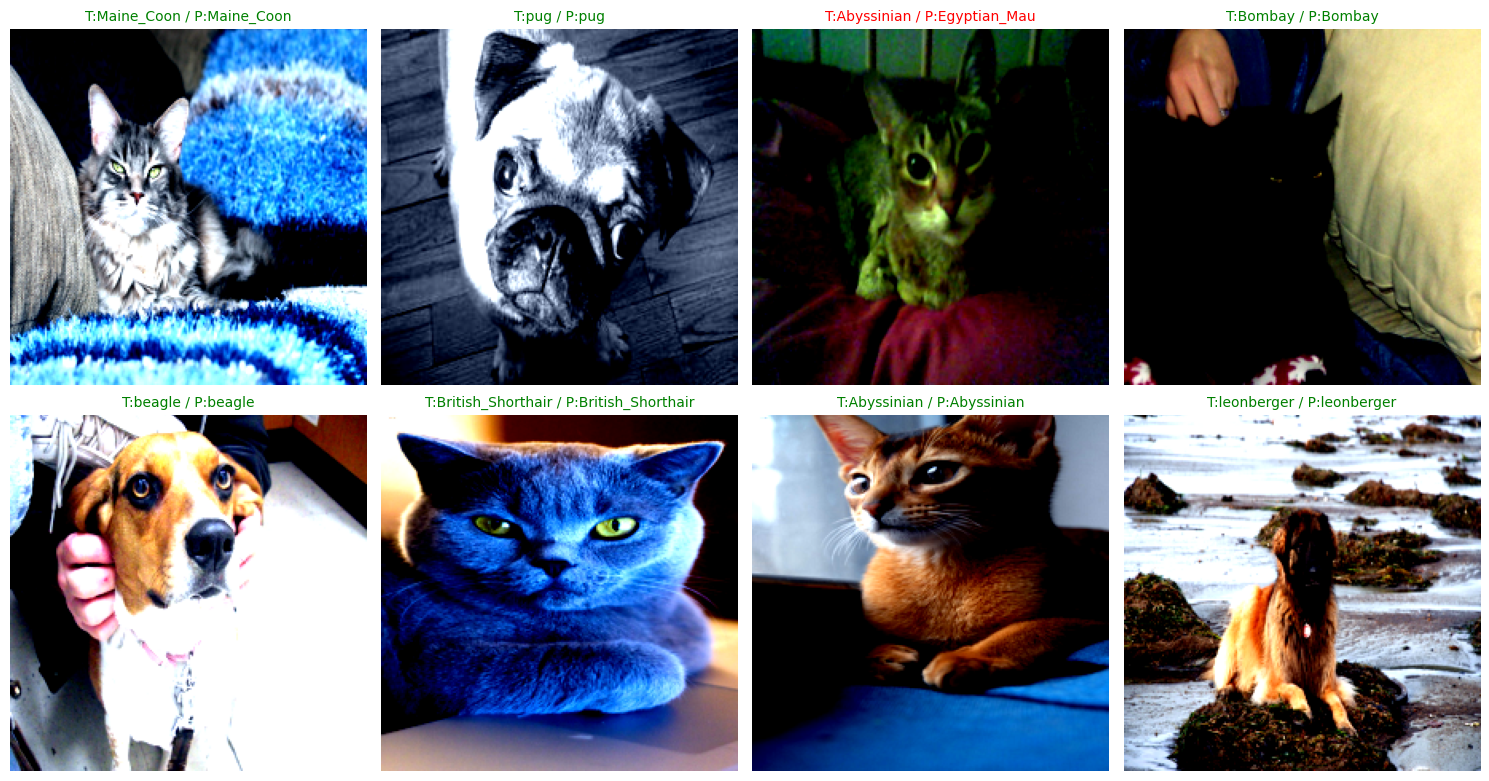

In [88]:
show_val_predictions_race(model_vgg, test_loader, race_names=breed_names, device=device)

In [56]:
!pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu130


Looking in indexes: https://download.pytorch.org/whl/cu130
